In [8]:
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

import build_speed as bs
import fast_marching as fm
import calculate_errors as ce

c:\Users\mperuzzo\OneDrive - Nexus365\Documents\bottlenecks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# load data
crop = 'wheat'
layers = []
dataset = loadmat(f'data/{crop}/raw_data.mat')['raw_data']

dt = 40

# start point
dataset[:,2] = dataset[:,2] - 1
start_point = dataset[np.where(dataset[:,2] == 0)[0][0],:]

In [14]:
thetas = np.linspace(-1, 1, 101)
error_list = []
for theta in tqdm(thetas, desc='Evaluating theta'):
    theta = np.array([theta])
    S = bs.build_speed(crop, theta, layers)
    T = fm.fast_marching(S, [tuple(start_point)])
    error_list.append(ce.calculate_mse(dataset, T, dt))

Evaluating theta: 100%|██████████| 101/101 [02:30<00:00,  1.49s/it]


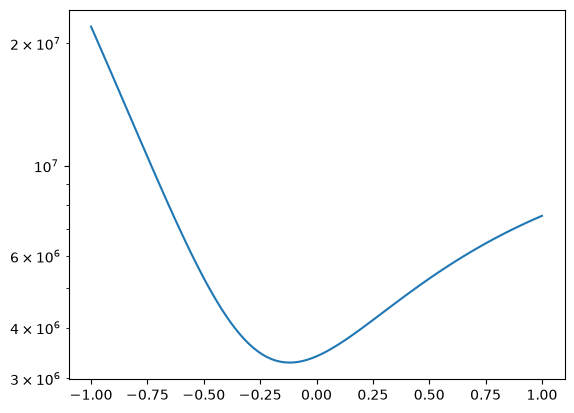

In [15]:
plt.semilogy(thetas, error_list)